# Planar Pushing: Constrained Covariance Extraction

Based on the contact-rich scenario from Guo et al. (ICRA 2025) and InCOpt (Qadri et al., IROS 2022).

We demonstrate:
1. Constrained covariance extraction via tangent-space projection
2. Trajectory-wide locality diagnostics (curvature, reach, spread)
3. Directional noise stress test (normal vs tangential)

**Requires:** `numpy`, `scipy`, `matplotlib`

In [1]:
import numpy as np
from scipy.optimize import minimize
from scipy.linalg import block_diag, null_space
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

np.random.seed(42)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
})

## 1. Helper Functions

In [2]:
def wrap_to_pi(angles):
    return (angles + np.pi) % (2 * np.pi) - np.pi

def wrap_angle_in_state(x):
    x = x.copy()
    x[2] = wrap_to_pi(x[2])
    return x

def rot2d(angle):
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c, -s], [s, c]])

def get_box_corners(box_pose, box_corners_box_frame):
    R = rot2d(box_pose[2])
    return R @ box_corners_box_frame + box_pose[:2, np.newaxis]

def p_poly_dist(x, y, xv, yv):
    """Signed distance from point (x,y) to polygon (xv,yv)."""
    xv = np.asarray(xv, dtype=float).flatten()
    yv = np.asarray(yv, dtype=float).flatten()
    if xv[0] != xv[-1] or yv[0] != yv[-1]:
        xv = np.append(xv, xv[0])
        yv = np.append(yv, yv[0])
    A = -np.diff(yv); B = np.diff(xv)
    C = yv[1:]*xv[:-1] - xv[1:]*yv[:-1]
    AB = 1.0 / (A**2 + B**2)
    vv = A*x + B*y + C
    xp = x - (A*AB)*vv; yp = y - (B*AB)*vv
    idx_vert = np.where(np.diff(xv) == 0)[0]; xp[idx_vert] = xv[idx_vert]
    idx_horiz = np.where(np.diff(yv) == 0)[0]; yp[idx_horiz] = yv[idx_horiz]
    idx_x = (xp >= np.minimum(xv[:-1], xv[1:])) & (xp <= np.maximum(xv[:-1], xv[1:]))
    idx_y = (yp >= np.minimum(yv[:-1], yv[1:])) & (yp <= np.maximum(yv[:-1], yv[1:]))
    idx_inside = idx_x & idx_y
    dists = np.full(len(A), np.inf)
    if np.any(idx_inside):
        dists[idx_inside] = np.abs(vv[idx_inside]) * np.sqrt(AB[idx_inside])
    for i in range(len(A)):
        if not idx_inside[i]:
            d1 = np.sqrt((x - xv[i])**2 + (y - yv[i])**2)
            d2 = np.sqrt((x - xv[i+1])**2 + (y - yv[i+1])**2)
            dists[i] = min(d1, d2)
    d_min = np.min(dists)
    # Sign: negative if inside polygon (ray-casting)
    cn = 0
    for i in range(len(xv)-1):
        if ((yv[i] <= y < yv[i+1]) or (yv[i+1] <= y < yv[i])):
            vt = (y - yv[i]) / (yv[i+1] - yv[i])
            if x < xv[i] + vt * (xv[i+1] - xv[i]):
                cn += 1
    sign = -1.0 if (cn % 2 == 1) else 1.0
    return sign * d_min

def plot_cov_ellipse(ax, mu, cov, n_std=3, **kwargs):
    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 0)
    if np.max(vals) < 1e-15: return None
    order = vals.argsort()[::-1]; vals = vals[order]; vecs = vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))
    width = 2*n_std*np.sqrt(vals[0]); height = 2*n_std*np.sqrt(vals[1])
    e = Ellipse(xy=mu, width=width, height=height, angle=angle, fill=False, **kwargs)
    ax.add_patch(e); return e

def numdiff(fn, x):
    """Numerical Jacobian via central differences."""
    eps_val = 1e-7
    n_i, n_j = x.shape; val = fn(x).flatten(); m = len(val); n = n_i*n_j
    J = np.zeros((m, n))
    for k in range(n):
        h = np.zeros((n_i, n_j))
        col, row = divmod(k, n_i); h[row, col] = eps_val
        J[:, k] = (fn(x+h) - fn(x-h)) / (2*eps_val)
    return J.T

## 2. Scenario Setup

A rectangular box $(w=0.2, h=1.0)$ m is pushed by a circular probe ($r_p=0.1$ m).  
State: $x_k = (p_x, p_y, \theta) \in \mathbb{R}^2 \times S^1$, with per-step contact constraint $c_k(x_k) = 0$.

In [3]:
probe_radius = 0.1
box_w, box_h = 0.2, 1.0
n_steps = 50

probe_to_box_dist = probe_radius + box_w / 2
box_corners_box_frame = np.array([
    [-box_w/2, box_w/2, box_w/2, -box_w/2],
    [box_h/2, box_h/2, -box_h/2, -box_h/2]
])

# Probe trajectory (noiseless)
probe_pos = np.array([np.linspace(1, 3, n_steps), -np.linspace(0, 1.5, n_steps)**2])

# Ground-truth box trajectory
box_coord_relative = np.array([
    np.zeros(n_steps),
    np.linspace(0, -np.pi/6, n_steps)
])
box_coord_global = np.array([
    probe_pos[0] + probe_to_box_dist,
    probe_pos[1] + box_coord_relative[0],
    box_coord_relative[1]
])

# Adjust x-coordinate so ground-truth box touches the probe
print('Adjusting ground truth to satisfy contact constraints...')
for i in range(n_steps):
    corners_i = get_box_corners(box_coord_global[:, i], box_corners_box_frame)
    def dist_obj(dx, c=corners_i, idx=i):
        return (p_poly_dist(probe_pos[0,idx], probe_pos[1,idx], c[0]+dx[0], c[1]) - probe_radius)**2
    res = minimize(dist_obj, [0.0], method='BFGS', options={'disp': False, 'gtol': 1e-10})
    box_coord_global[0, i] += res.x[0]

print('Ground truth adjusted.')

Adjusting ground truth to satisfy contact constraints...
Ground truth adjusted.


## 3. Generate Odometry and Optimize Constrained Trajectory

In [4]:
Q = np.diag([0.03**2, 0.03**2, 0.01**2])
Q_inv = np.linalg.inv(Q)

u_noiseless = wrap_angle_in_state(box_coord_global[:, 1:] - box_coord_global[:, :-1])
noise = np.random.multivariate_normal([0,0,0], Q, n_steps-1).T
u = wrap_angle_in_state(u_noiseless + noise)

n_vars = n_steps - 1
x0 = box_coord_global[:, 0]
x_init = box_coord_global[:, 1:].flatten(order='F')
probe_pos_sub = probe_pos[:, 1:]

def compute_cost(x_flat, x0, u, Q_inv, n_vars):
    x = x_flat.reshape(3, n_vars, order='F')
    full_x = np.column_stack([x0, x])
    predicted = wrap_angle_in_state(full_x[:, :-1] + u)
    residual = wrap_angle_in_state(full_x[:, 1:] - predicted)
    cost = sum(r @ Q_inv @ r for r in residual.T)
    return cost

def box_touch_probe_constraint(x_flat, probe_pos_sub, probe_radius, bcbf, n_vars):
    x = x_flat.reshape(3, n_vars, order='F')
    ceq = np.zeros(n_vars)
    for i in range(n_vars):
        corners = get_box_corners(x[:, i], bcbf)
        ceq[i] = p_poly_dist(probe_pos_sub[0,i], probe_pos_sub[1,i], corners[0], corners[1]) - probe_radius
    return ceq

constraints = {'type': 'eq', 'fun': lambda xf: box_touch_probe_constraint(
    xf, probe_pos_sub, probe_radius, box_corners_box_frame, n_vars)}

print('Optimizing constrained trajectory (may take a minute)...')
result = minimize(compute_cost, x_init, args=(x0, u, Q_inv, n_vars),
                  method='SLSQP', constraints=constraints,
                  options={'maxiter': 50000, 'disp': True, 'ftol': 1e-12})
x_opt = result.x.reshape(3, n_vars, order='F')
print(f'Converged: {result.success}')

Optimizing constrained trajectory (may take a minute)...


Optimization terminated successfully    (Exit mode 0)
            Current function value: 52.72538629139552
            Iterations: 105
            Function evaluations: 15968
            Gradient evaluations: 105
Converged: True


## 4. Compute Unconstrained and Constrained Covariance

The key step: tangent-space conditioning via $\Sigma_{\mathrm{con}} = N(N^\top F N)^{-1} N^\top$.

In [5]:
# Gauss-Newton information matrix
dim = n_vars * 3
H = np.zeros((dim, dim))
for i in range(n_vars):
    H[i*3:(i+1)*3, i*3:(i+1)*3] = -np.eye(3)
    if i < n_vars - 1:
        H[(i+1)*3:(i+2)*3, i*3:(i+1)*3] = np.eye(3)

W = block_diag(*[Q for _ in range(n_vars)])
unconstrained_info = H.T @ np.linalg.solve(W, H)
unconstrained_cov = np.linalg.inv(unconstrained_info)

# Linearize contact constraints
def constr_eq_fn(x_mat):
    nv = x_mat.shape[1]
    ceq = np.zeros(nv)
    for i in range(nv):
        corners = get_box_corners(x_mat[:, i], box_corners_box_frame)
        ceq[i] = p_poly_dist(probe_pos_sub[0,i], probe_pos_sub[1,i], corners[0], corners[1]) - probe_radius
    return ceq

S = numdiff(constr_eq_fn, x_opt)
N = null_space(S.T)

# *** This is the core 3-line constrained covariance extraction ***
constrained_cov = N @ np.linalg.solve(N.T @ unconstrained_info @ N, N.T)

print(f'Unconstrained cov shape: {unconstrained_cov.shape}')
print(f'Constrained cov shape: {constrained_cov.shape}')
print(f'Null space dimension: {N.shape[1]} (= {n_vars} poses x 3 DOF - {n_vars} constraints = {n_vars*2} tangent DOF)')

Unconstrained cov shape: (147, 147)
Constrained cov shape: (147, 147)
Null space dimension: 98 (= 49 poses x 3 DOF - 49 constraints = 98 tangent DOF)


## 5. Covariance Reduction Analysis

In [6]:
timesteps_show = [0, 12, 24, 36, 48]  # indices (0-based) ~ k=1,13,25,37,49

print(f'{"k":>3} | {"tr(Σ_xy) Unc":>12} | {"tr(Σ_xy) Con":>12} | {"λ_max Unc":>10} | {"λ_max Con":>10} | {"Red.%":>6} | {"‖ΔΣ‖_F":>8}')
print('-' * 80)

for idx in timesteps_show:
    i3 = idx * 3
    Sigma_unc_xy = unconstrained_cov[i3:i3+2, i3:i3+2]
    Sigma_con_xy = constrained_cov[i3:i3+2, i3:i3+2]
    tr_unc = np.trace(Sigma_unc_xy)
    tr_con = np.trace(Sigma_con_xy)
    lam_unc = np.max(np.linalg.eigvalsh(Sigma_unc_xy))
    lam_con = np.max(np.linalg.eigvalsh(Sigma_con_xy))
    red = (1 - tr_con/tr_unc) * 100
    frob = np.linalg.norm(Sigma_unc_xy - Sigma_con_xy, 'fro')
    print(f'{idx+1:>3} | {tr_unc:>12.4f} | {tr_con:>12.4f} | {lam_unc:>10.4f} | {lam_con:>10.4f} | {red:>5.1f}% | {frob:>8.4f}')

  k | tr(Σ_xy) Unc | tr(Σ_xy) Con |  λ_max Unc |  λ_max Con |  Red.% |   ‖ΔΣ‖_F
--------------------------------------------------------------------------------
  1 |       0.0018 |       0.0009 |     0.0009 |     0.0009 |  50.5% |   0.0009
 13 |       0.0234 |       0.0105 |     0.0117 |     0.0105 |  55.3% |   0.0118
 25 |       0.0450 |       0.0190 |     0.0225 |     0.0190 |  57.8% |   0.0228
 37 |       0.0666 |       0.0278 |     0.0333 |     0.0278 |  58.2% |   0.0337
 49 |       0.0882 |       0.0377 |     0.0441 |     0.0377 |  57.3% |   0.0446


## 6. Scenario Visualization with Covariance Ellipses

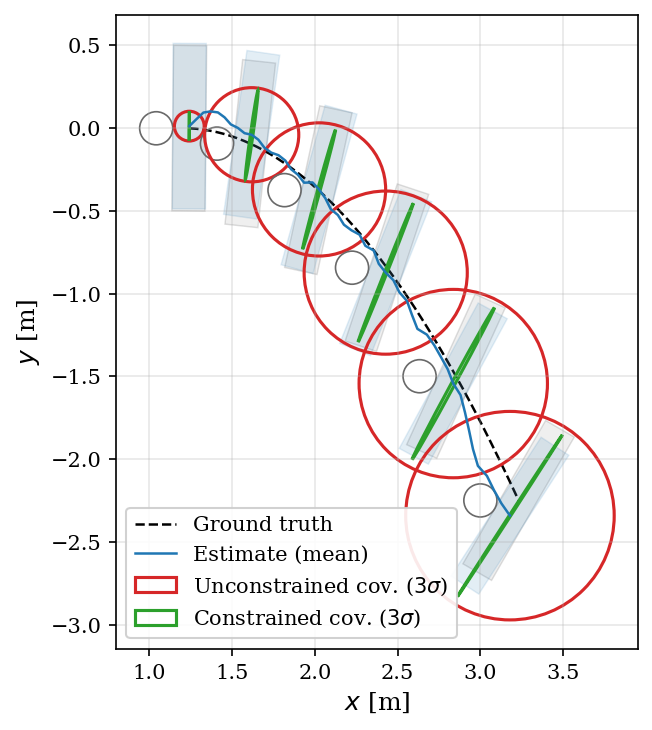

In [7]:
from matplotlib.patches import Polygon as MplPolygon, Circle as MplCircle

fig, ax = plt.subplots(figsize=(7, 5))

display_indices = [0, 9, 19, 29, 39, n_vars - 1]

# Trajectories
ax.plot(box_coord_global[0, 1:], box_coord_global[1, 1:],
        'k--', lw=1.2, label='Ground truth', zorder=1)
ax.plot(x_opt[0], x_opt[1], '-', color='tab:blue', lw=1.2,
        label='Estimate (mean)', zorder=2)

for idx_i, i in enumerate(display_indices):
    # Ground-truth box
    bc_gt = get_box_corners(box_coord_global[:, i + 1], box_corners_box_frame)
    ax.add_patch(MplPolygon(bc_gt.T, closed=True, facecolor='gray',
                             alpha=0.12, edgecolor='black', lw=0.7))
    # Estimated box
    bc_est = get_box_corners(x_opt[:, i], box_corners_box_frame)
    ax.add_patch(MplPolygon(bc_est.T, closed=True, facecolor='tab:blue',
                             alpha=0.12, edgecolor='tab:blue', lw=0.7))
    # Probe circle
    ax.add_patch(MplCircle(probe_pos[:, i + 1], probe_radius,
                            fill=False, edgecolor='dimgray', lw=0.8))
    # Unconstrained covariance ellipse (3-sigma, xy marginal)
    i3 = i * 3
    unc_cov_xy = unconstrained_cov[i3:i3+2, i3:i3+2]
    plot_cov_ellipse(ax, x_opt[:2, i], unc_cov_xy, n_std=3,
                     edgecolor='tab:red', linewidth=1.5,
                     label=r'Unconstrained cov. ($3\sigma$)' if idx_i == 0 else None)
    # Constrained covariance ellipse (3-sigma, xy marginal)
    con_cov_xy = constrained_cov[i3:i3+2, i3:i3+2]
    plot_cov_ellipse(ax, x_opt[:2, i], con_cov_xy, n_std=3,
                     edgecolor='tab:green', linewidth=1.5,
                     label=r'Constrained cov. ($3\sigma$)' if idx_i == 0 else None)

ax.set_aspect('equal')
ax.set_xlabel('$x$ [m]'); ax.set_ylabel('$y$ [m]')
ax.legend(loc='lower left', framealpha=0.9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 7. Trajectory-Wide Locality Diagnostics

At each timestep, compute curvature/reach proxies and compare tangent-plane covariance against Monte Carlo projection.

In [8]:
def estimate_local_geometry(x_mean, probe_pos_i, probe_radius, bcbf, eps_fd=1e-6):
    """Estimate gradient, Hessian, curvature and reach proxies at one timestep."""
    def c_val(x):
        corners = get_box_corners(x, bcbf)
        return p_poly_dist(probe_pos_i[0], probe_pos_i[1], corners[0], corners[1]) - probe_radius
    
    grad = np.zeros(3)
    for j in range(3):
        e = np.zeros(3); e[j] = eps_fd
        grad[j] = (c_val(x_mean+e) - c_val(x_mean-e)) / (2*eps_fd)
    
    hess = np.zeros((3,3))
    for a in range(3):
        ea = np.zeros(3); ea[a] = eps_fd
        for b in range(a, 3):
            eb = np.zeros(3); eb[b] = eps_fd
            hess[a,b] = (c_val(x_mean+ea+eb) - c_val(x_mean+ea-eb) - c_val(x_mean-ea+eb) + c_val(x_mean-ea-eb)) / (4*eps_fd**2)
            hess[b,a] = hess[a,b]
    
    grad_norm = max(np.linalg.norm(grad), 1e-12)
    N_i = null_space(grad.reshape(1,3))
    if N_i.shape[1] < 2:
        normal = grad / grad_norm
        v = N_i[:, 0] if N_i.shape[1] > 0 else np.array([normal[1], -normal[0], 0.])
        w = np.cross(normal, v); w /= max(np.linalg.norm(w), 1e-12)
        N_i = np.column_stack([v, w])
    Pi_i = N_i @ N_i.T
    shape_op = (N_i.T @ hess @ N_i) / grad_norm
    kappa = float(np.max(np.abs(np.linalg.eigvalsh(shape_op)))) if shape_op.size > 0 else 0.0
    rho = np.inf if kappa < 1e-10 else 1.0 / kappa
    return {'projector': Pi_i, 'curvature': kappa, 'reach': rho}

def project_sample(x_sample, probe_pos_i, probe_radius, bcbf):
    def obj(x): return np.sum((x - x_sample)**2)
    def con(x):
        corners = get_box_corners(x, bcbf)
        return p_poly_dist(probe_pos_i[0], probe_pos_i[1], corners[0], corners[1]) - probe_radius
    res = minimize(obj, x_sample, method='SLSQP', constraints={'type':'eq','fun':con}, options={'maxiter':120,'ftol':1e-9})
    return res.x, res.success

In [9]:
n_mc = 120  # Monte Carlo samples per timestep (increase for smoother results)
diag_results = {'kappa': [], 'rho': [], 'spread': [], 'locality': [],
                'rho_mc': [], 'delta_mc': []}

print('Running trajectory-wide diagnostics (this may take several minutes)...')
for k in range(n_vars):
    if k % 10 == 0:
        print(f'  timestep {k+1}/{n_vars}')
    i3 = k * 3
    x_mean = x_opt[:, k]
    Sigma_unc_k = unconstrained_cov[i3:i3+3, i3:i3+3]
    
    geom = estimate_local_geometry(x_mean, probe_pos_sub[:, k], probe_radius, box_corners_box_frame)
    s_k = np.sqrt(np.max(np.linalg.eigvalsh(Sigma_unc_k)))
    
    diag_results['kappa'].append(geom['curvature'])
    diag_results['rho'].append(geom['reach'])
    diag_results['spread'].append(s_k)
    diag_results['locality'].append(s_k / geom['reach'] if np.isfinite(geom['reach']) else 0.0)
    
    # MC comparison
    Sigma_lin_xy = (geom['projector'] @ Sigma_unc_k @ geom['projector'].T)[:2, :2]
    samples = np.random.multivariate_normal(x_mean, Sigma_unc_k, n_mc)
    projected = []
    for j in range(n_mc):
        proj, ok = project_sample(samples[j], probe_pos_sub[:, k], probe_radius, box_corners_box_frame)
        if ok:
            projected.append(proj)
    if len(projected) > 10:
        projected = np.array(projected)
        Sigma_mc_xy = np.cov(projected[:, :2].T, bias=False)
        rho_mc = np.trace(Sigma_mc_xy) / max(np.trace(Sigma_lin_xy), 1e-15)
        delta_mc = np.linalg.norm(Sigma_mc_xy - Sigma_lin_xy, 'fro') / max(np.linalg.norm(Sigma_lin_xy, 'fro'), 1e-15)
    else:
        rho_mc = np.nan; delta_mc = np.nan
    diag_results['rho_mc'].append(rho_mc)
    diag_results['delta_mc'].append(delta_mc)

for key in diag_results:
    diag_results[key] = np.array(diag_results[key])
print('Done.')

Running trajectory-wide diagnostics (this may take several minutes)...
  timestep 1/49


  timestep 11/49


  timestep 21/49


  timestep 31/49


  timestep 41/49


Done.


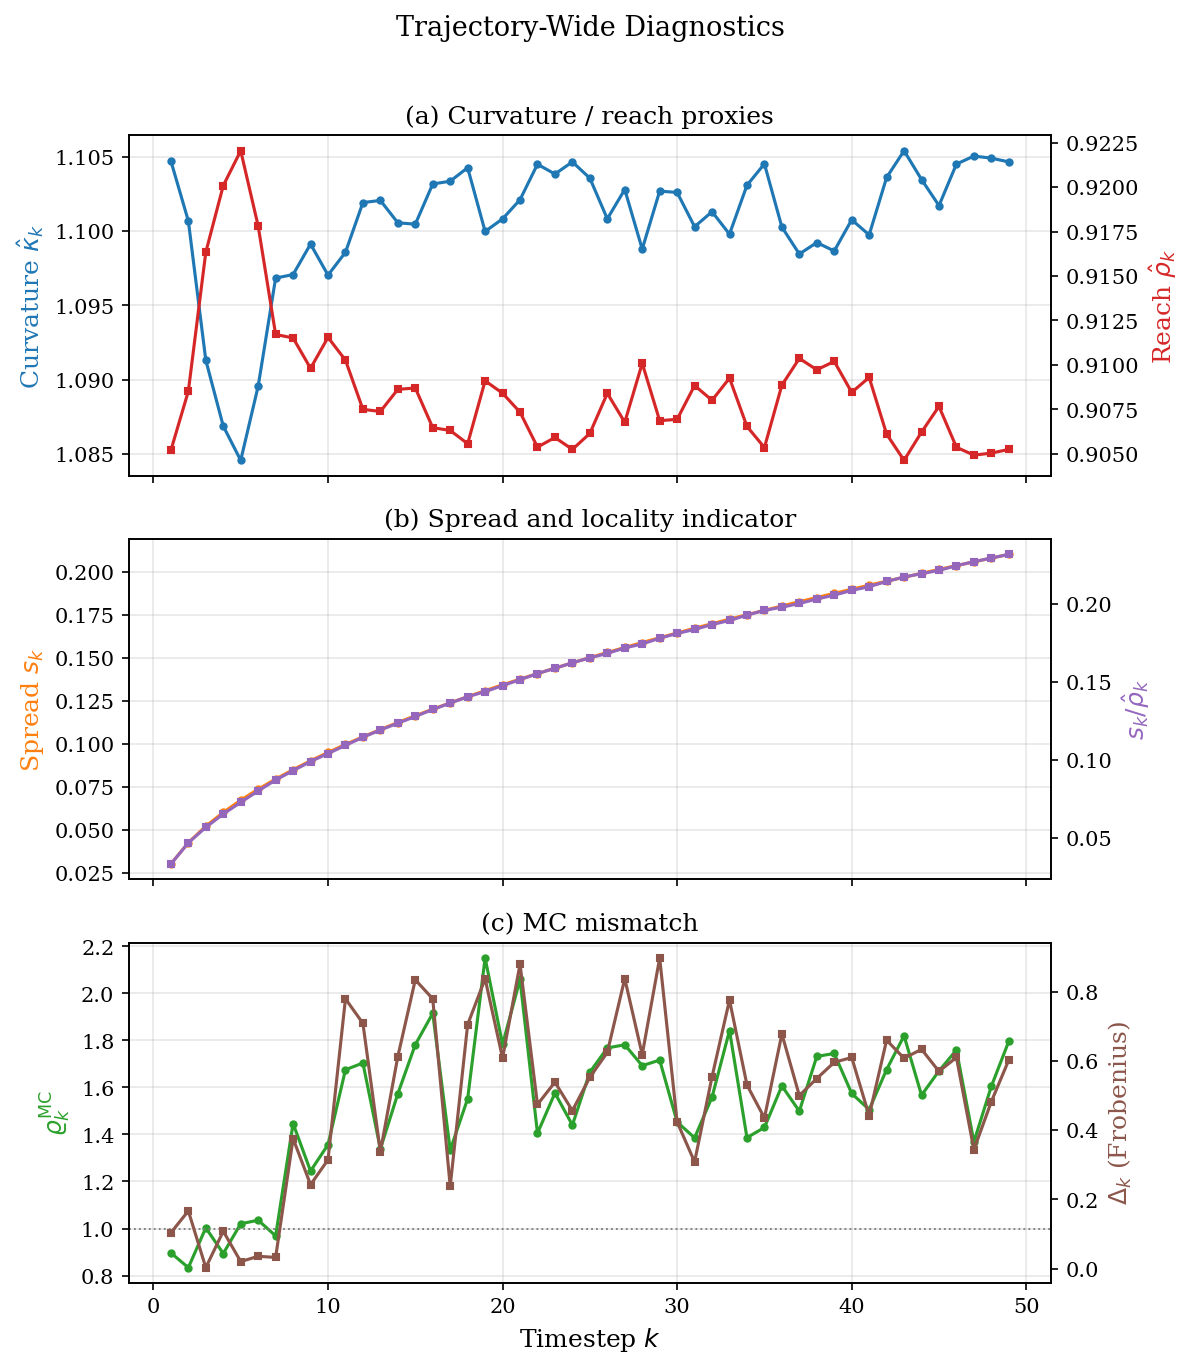

Median ρ_MC: 1.573
Median Δ_k:  0.553
Max locality s_k/ρ_k: 0.232


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
timesteps = np.arange(1, n_vars + 1)

# (a) Curvature and reach
ax = axes[0]
ax.plot(timesteps, diag_results['kappa'], 'o-', ms=3, color='C0', label=r'$\hat{\kappa}_k$')
ax2 = ax.twinx()
ax2.plot(timesteps, diag_results['rho'], 's-', ms=3, color='C3', label=r'$\hat{\rho}_k$')
ax.set_ylabel(r'Curvature $\hat{\kappa}_k$', color='C0')
ax2.set_ylabel(r'Reach $\hat{\rho}_k$', color='C3')
ax.set_title('(a) Curvature / reach proxies')
ax.grid(True, alpha=0.3)

# (b) Spread and locality indicator
ax = axes[1]
ax.plot(timesteps, diag_results['spread'], 'o-', ms=3, color='C1', label=r'$s_k$')
ax2 = ax.twinx()
ax2.plot(timesteps, diag_results['locality'], 's-', ms=3, color='C4', label=r'$s_k/\hat{\rho}_k$')
ax.set_ylabel(r'Spread $s_k$', color='C1')
ax2.set_ylabel(r'$s_k/\hat{\rho}_k$', color='C4')
ax.set_title('(b) Spread and locality indicator')
ax.grid(True, alpha=0.3)

# (c) MC mismatch
ax = axes[2]
ax.plot(timesteps, diag_results['rho_mc'], 'o-', ms=3, color='C2', label=r'$\varrho_k^{\mathrm{MC}}$')
ax2 = ax.twinx()
ax2.plot(timesteps, diag_results['delta_mc'], 's-', ms=3, color='C5', label=r'$\Delta_k$')
ax.axhline(1.0, color='gray', ls=':', lw=0.9)
ax.set_ylabel(r'$\varrho_k^{\mathrm{MC}}$', color='C2')
ax2.set_ylabel(r'$\Delta_k$ (Frobenius)', color='C5')
ax.set_title('(c) MC mismatch')
ax.set_xlabel('Timestep $k$')
ax.grid(True, alpha=0.3)

plt.suptitle('Trajectory-Wide Diagnostics', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Summary statistics
valid = ~np.isnan(diag_results['rho_mc'])
print(f"Median ρ_MC: {np.nanmedian(diag_results['rho_mc']):.3f}")
print(f"Median Δ_k:  {np.nanmedian(diag_results['delta_mc']):.3f}")
print(f"Max locality s_k/ρ_k: {np.max(diag_results['locality']):.3f}")

## 8. Directional Noise Stress Test

At the terminal pose, independently scale normal and tangential uncertainty to test which direction drives mismatch.

In [11]:
k_star = n_vars - 1
i3_star = k_star * 3
x_star = x_opt[:, k_star]
Sigma_unc_star = unconstrained_cov[i3_star:i3_star+3, i3_star:i3_star+3]
geom_star = estimate_local_geometry(x_star, probe_pos_sub[:, k_star], probe_radius, box_corners_box_frame)

# Get unit normal at terminal pose
def c_val_star(x):
    corners = get_box_corners(x, box_corners_box_frame)
    return p_poly_dist(probe_pos_sub[0,k_star], probe_pos_sub[1,k_star], corners[0], corners[1]) - probe_radius

grad = np.zeros(3)
eps_fd = 1e-6
for j in range(3):
    e = np.zeros(3); e[j] = eps_fd
    grad[j] = (c_val_star(x_star+e) - c_val_star(x_star-e)) / (2*eps_fd)
n_hat = grad / np.linalg.norm(grad)

noise_scales = [0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0]
n_mc_dir = 200

dir_results = {'iso': {'ratios': [], 'deltas': []},
               'normal': {'ratios': [], 'deltas': []},
               'tangent': {'ratios': [], 'deltas': []}}

print('Running directional noise study...')
for alpha in noise_scales:
    for mode, (a_n, a_t) in [('iso', (alpha, alpha)),
                               ('normal', (alpha, 1.0)),
                               ('tangent', (1.0, alpha))]:
        A = a_t * (np.eye(3) - np.outer(n_hat, n_hat)) + a_n * np.outer(n_hat, n_hat)
        Sigma_scaled = A @ Sigma_unc_star @ A.T
        
        Sigma_lin_xy = (geom_star['projector'] @ Sigma_scaled @ geom_star['projector'].T)[:2, :2]
        samples = np.random.multivariate_normal(x_star, Sigma_scaled, n_mc_dir)
        projected = []
        for j in range(n_mc_dir):
            proj, ok = project_sample(samples[j], probe_pos_sub[:, k_star], probe_radius, box_corners_box_frame)
            if ok:
                projected.append(proj)
        if len(projected) > 10:
            projected = np.array(projected)
            Sigma_mc_xy = np.cov(projected[:, :2].T, bias=False)
            rho_mc = np.trace(Sigma_mc_xy) / max(np.trace(Sigma_lin_xy), 1e-15)
            delta_mc = np.linalg.norm(Sigma_mc_xy - Sigma_lin_xy, 'fro') / max(np.linalg.norm(Sigma_lin_xy, 'fro'), 1e-15)
        else:
            rho_mc = np.nan; delta_mc = np.nan
        dir_results[mode]['ratios'].append(rho_mc)
        dir_results[mode]['deltas'].append(delta_mc)

print('Done.')

Running directional noise study...


Done.


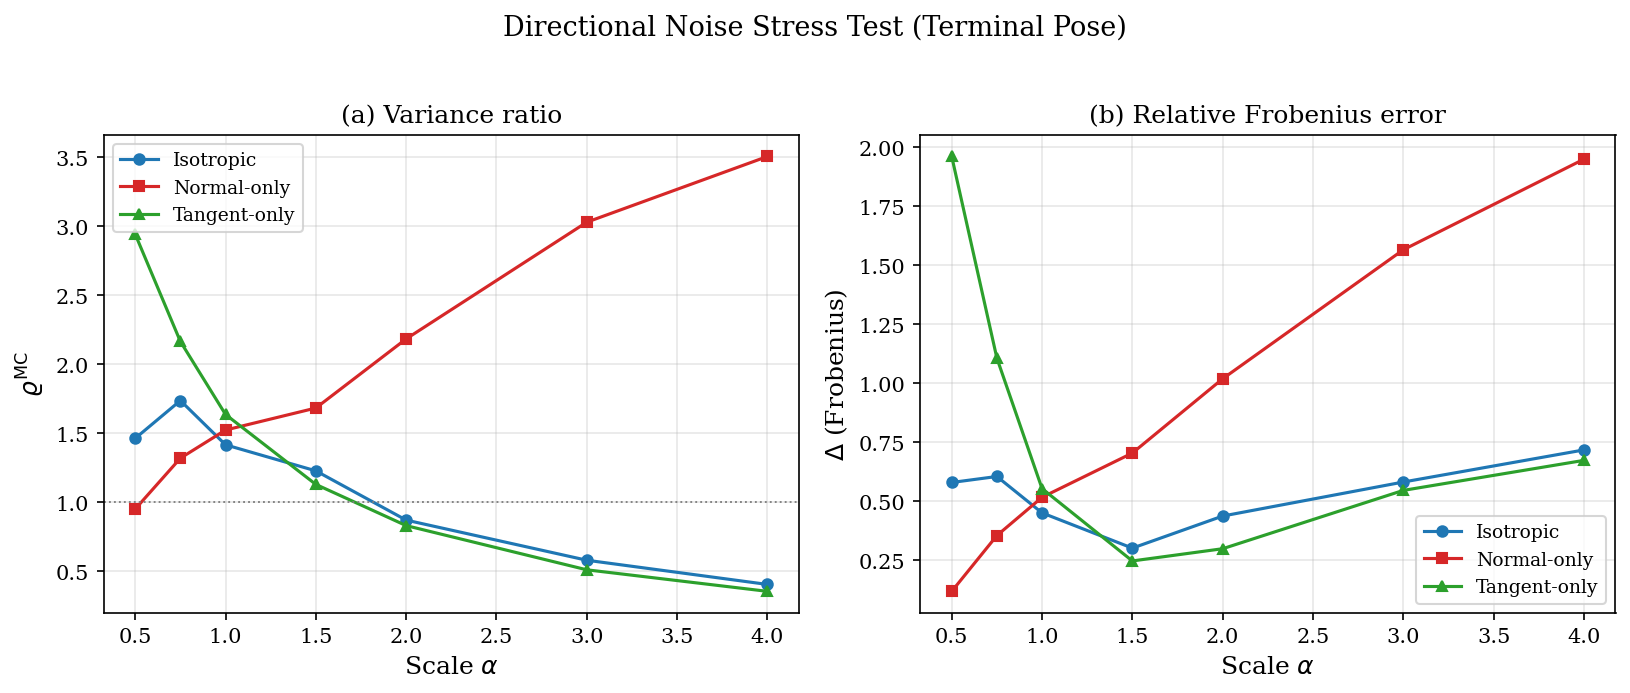

Normal-direction inflation causes the largest calibration mismatch,
consistent with the theoretical prediction that normal-direction
uncertainty is the dominant failure mode.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
styles = {'iso': ('C0', 'o', 'Isotropic'), 'normal': ('C3', 's', 'Normal-only'), 'tangent': ('C2', '^', 'Tangent-only')}

for ax, (metric, ylabel, title) in zip(axes, [
    ('ratios', r'$\varrho^{\mathrm{MC}}$', '(a) Variance ratio'),
    ('deltas', r'$\Delta$ (Frobenius)', '(b) Relative Frobenius error')
]):
    for mode, (color, marker, label) in styles.items():
        ax.plot(noise_scales, dir_results[mode][metric], f'-{marker}', ms=5, color=color, label=label)
    if metric == 'ratios':
        ax.axhline(1.0, color='gray', ls=':', lw=0.9)
    ax.set_xlabel(r'Scale $\alpha$'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Directional Noise Stress Test (Terminal Pose)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print('Normal-direction inflation causes the largest calibration mismatch,\n'
      'consistent with the theoretical prediction that normal-direction\n'
      'uncertainty is the dominant failure mode.')

## 5b. Covariance Metrics Figure

Four-panel figure:
- (a) Position covariance trace over time
- (b) Position covariance eigenvalues over time
- (c) Full pose covariance eigenvalues (log scale)
- (d) Constraint-induced uncertainty reduction (%)

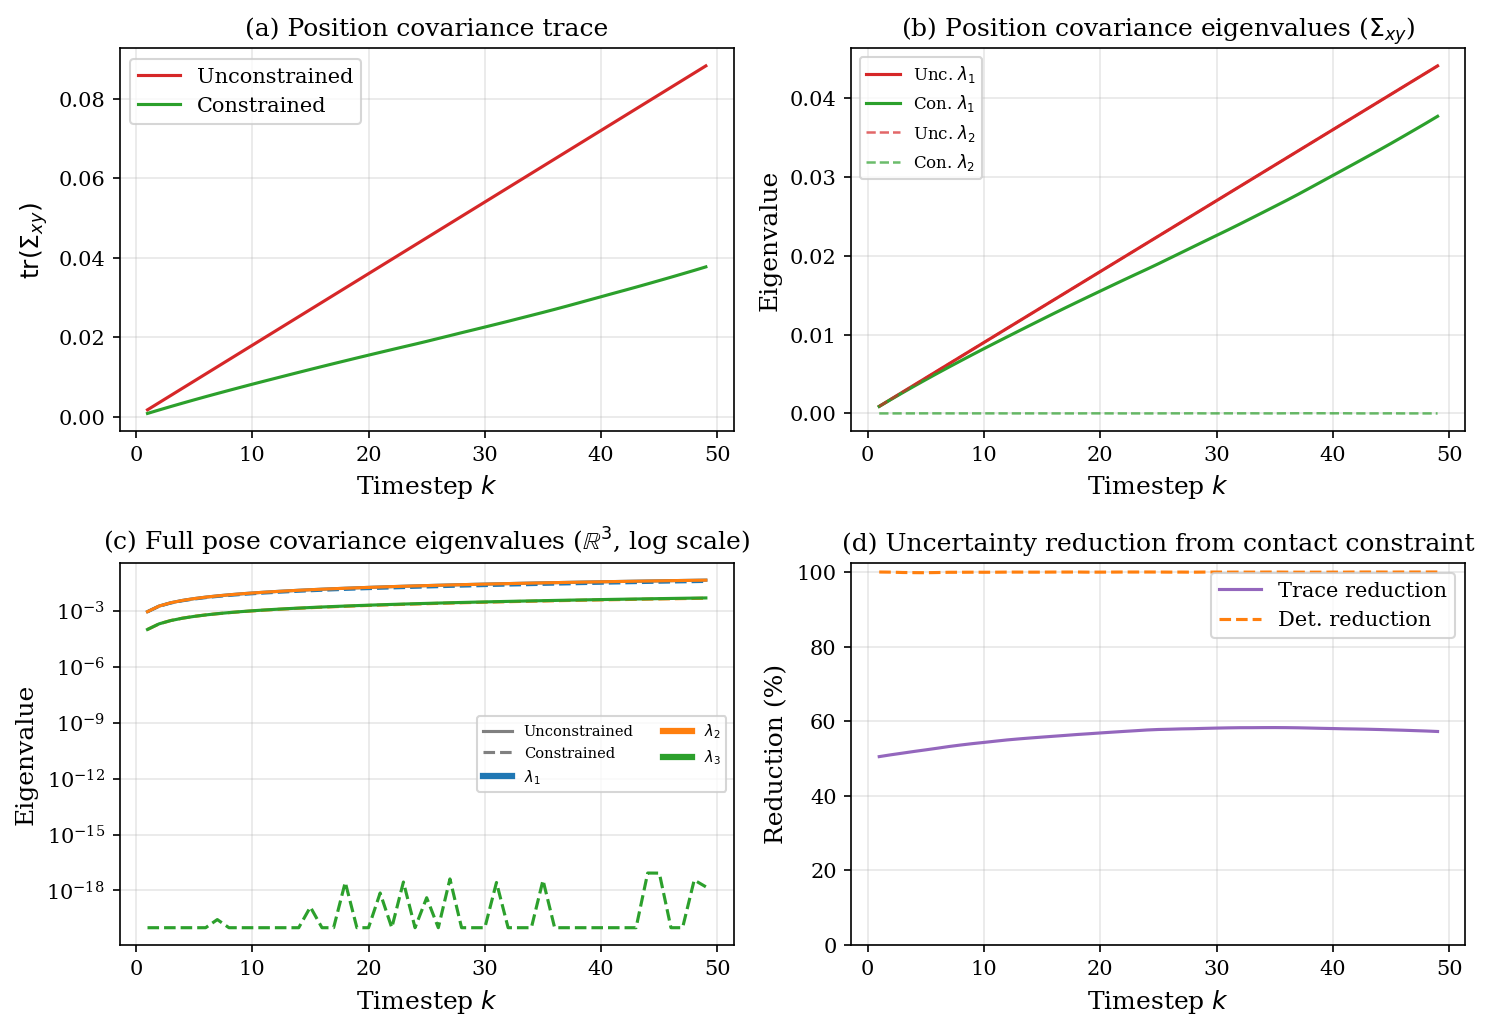

In [13]:
from matplotlib.lines import Line2D

# Compute trajectory-wide metrics
trace_unc_xy = np.zeros(n_vars)
trace_con_xy = np.zeros(n_vars)
eig_unc_xy = np.zeros((n_vars, 2))
eig_con_xy = np.zeros((n_vars, 2))
eig_unc_full = np.zeros((n_vars, 3))
eig_con_full = np.zeros((n_vars, 3))
det_unc_xy = np.zeros(n_vars)
det_con_xy = np.zeros(n_vars)
frob_diff_xy = np.zeros(n_vars)
frob_diff_full = np.zeros(n_vars)

for k in range(n_vars):
    i3 = k * 3
    S_unc = unconstrained_cov[i3:i3+3, i3:i3+3]
    S_con = constrained_cov[i3:i3+3, i3:i3+3]
    S_unc_xy = S_unc[:2, :2]
    S_con_xy = S_con[:2, :2]
    trace_unc_xy[k] = np.trace(S_unc_xy)
    trace_con_xy[k] = np.trace(S_con_xy)
    ev_unc = np.sort(np.linalg.eigvalsh(S_unc_xy))[::-1]
    ev_con = np.sort(np.linalg.eigvalsh(S_con_xy))[::-1]
    eig_unc_xy[k] = ev_unc
    eig_con_xy[k] = ev_con
    eig_unc_full[k] = np.sort(np.linalg.eigvalsh(S_unc))[::-1]
    eig_con_full[k] = np.sort(np.linalg.eigvalsh(S_con))[::-1]
    det_unc_xy[k] = max(np.linalg.det(S_unc_xy), 1e-30)
    det_con_xy[k] = max(np.linalg.det(S_con_xy), 1e-30)
    frob_diff_xy[k] = np.linalg.norm(S_unc_xy - S_con_xy, 'fro')
    frob_diff_full[k] = np.linalg.norm(S_unc - S_con, 'fro')

timesteps_all = np.arange(1, n_vars + 1)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# (a) trace comparison
ax = axes[0, 0]
ax.plot(timesteps_all, trace_unc_xy, '-', color='tab:red', lw=1.5, label='Unconstrained')
ax.plot(timesteps_all, trace_con_xy, '-', color='tab:green', lw=1.5, label='Constrained')
ax.set_xlabel('Timestep $k$'); ax.set_ylabel(r'$\mathrm{tr}(\Sigma_{xy})$')
ax.set_title('(a) Position covariance trace'); ax.legend(); ax.grid(True, alpha=0.3)

# (b) xy eigenvalue comparison
ax = axes[0, 1]
ax.plot(timesteps_all, eig_unc_xy[:, 0], '-', color='tab:red', lw=1.5, label=r'Unc. $\lambda_1$')
ax.plot(timesteps_all, eig_con_xy[:, 0], '-', color='tab:green', lw=1.5, label=r'Con. $\lambda_1$')
ax.plot(timesteps_all, eig_unc_xy[:, 1], '--', color='tab:red', lw=1.2, alpha=0.7, label=r'Unc. $\lambda_2$')
ax.plot(timesteps_all, eig_con_xy[:, 1], '--', color='tab:green', lw=1.2, alpha=0.7, label=r'Con. $\lambda_2$')
ax.set_xlabel('Timestep $k$'); ax.set_ylabel('Eigenvalue')
ax.set_title(r'(b) Position covariance eigenvalues ($\Sigma_{xy}$)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (c) full 3x3 eigenvalue spectrum (log scale)
ax = axes[1, 0]
eig_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for j in range(3):
    ax.semilogy(timesteps_all, eig_unc_full[:, j], '-', color=eig_colors[j], lw=1.5)
    ax.semilogy(timesteps_all, np.maximum(eig_con_full[:, j], 1e-20), '--',
                color=eig_colors[j], lw=1.5)
legend_elements = [
    Line2D([0], [0], color='gray', ls='-', label='Unconstrained'),
    Line2D([0], [0], color='gray', ls='--', label='Constrained'),
]
for j in range(3):
    legend_elements.append(
        Line2D([0], [0], color=eig_colors[j], ls='-', lw=3, label=rf'$\lambda_{j+1}$'))
ax.legend(handles=legend_elements, fontsize=7, ncol=2)
ax.set_xlabel('Timestep $k$'); ax.set_ylabel('Eigenvalue')
ax.set_title(r'(c) Full pose covariance eigenvalues ($\mathbb{R}^3$, log scale)')
ax.grid(True, alpha=0.3)

# (d) uncertainty reduction
ax = axes[1, 1]
reduction_trace = (1 - trace_con_xy / trace_unc_xy) * 100
reduction_det = (1 - det_con_xy / det_unc_xy) * 100
ax.plot(timesteps_all, reduction_trace, '-', color='tab:purple', lw=1.5, label='Trace reduction')
ax.plot(timesteps_all, reduction_det, '--', color='tab:orange', lw=1.5, label='Det. reduction')
ax.set_xlabel('Timestep $k$'); ax.set_ylabel('Reduction (%)')
ax.set_title('(d) Uncertainty reduction from contact constraint')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)

fig.tight_layout()
plt.show()

## 5c. Constraint Satisfaction Figure

Three-panel figure:
- (a) Contact constraint violation
- (b) Position estimation error vs. ground truth
- (c) Covariance difference Frobenius norm

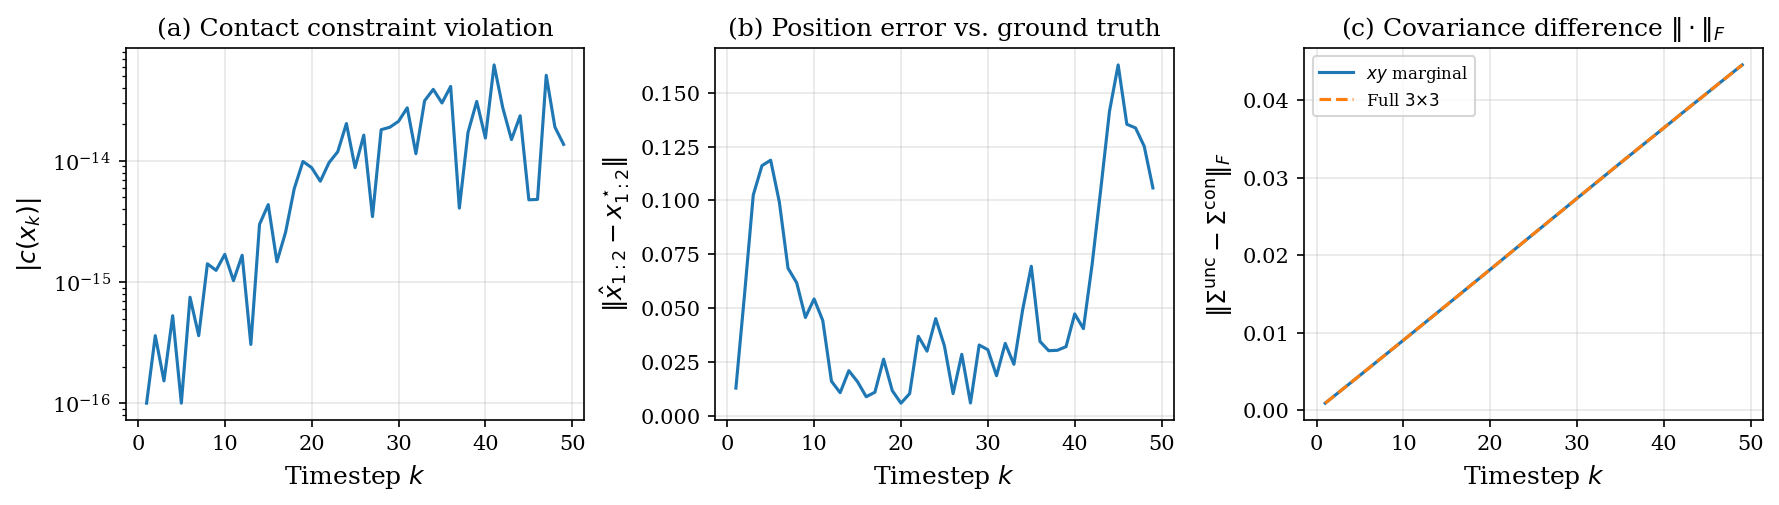

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# Compute constraint violation and position error
constraint_violation = np.zeros(n_vars)
position_error = np.zeros(n_vars)
for i in range(n_vars):
    corners = get_box_corners(x_opt[:, i], box_corners_box_frame)
    constraint_violation[i] = (
        p_poly_dist(probe_pos_sub[0, i], probe_pos_sub[1, i],
                    corners[0], corners[1]) - probe_radius)
    position_error[i] = np.linalg.norm(
        x_opt[:2, i] - box_coord_global[:2, i + 1])

# (a) constraint violation
ax = axes[0]
ax.semilogy(timesteps_all, np.maximum(np.abs(constraint_violation), 1e-16),
            '-', color='tab:blue', lw=1.5)
ax.set_xlabel('Timestep $k$'); ax.set_ylabel('$|c(x_k)|$')
ax.set_title('(a) Contact constraint violation'); ax.grid(True, alpha=0.3)

# (b) position error vs ground truth
ax = axes[1]
ax.plot(timesteps_all, position_error, '-', color='tab:blue', lw=1.5)
ax.set_xlabel('Timestep $k$')
ax.set_ylabel(r'$\|\hat{x}_{1:2} - x^\star_{1:2}\|$')
ax.set_title('(b) Position error vs. ground truth'); ax.grid(True, alpha=0.3)

# (c) covariance difference
ax = axes[2]
ax.plot(timesteps_all, frob_diff_xy, '-', color='tab:blue', lw=1.5,
        label=r'$xy$ marginal')
ax.plot(timesteps_all, frob_diff_full, '--', color='tab:orange', lw=1.5,
        label=r'Full $3{\times}3$')
ax.set_xlabel('Timestep $k$')
ax.set_ylabel(r'$\|\Sigma^{\mathrm{unc}} - \Sigma^{\mathrm{con}}\|_F$')
ax.set_title(r'(c) Covariance difference $\|\cdot\|_F$')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 7b. Enhanced Temporal Diagnostics

Three-panel figure matching the original script's temporal diagnostics:
- (a) Curvature / reach proxies
- (b) Spread, locality ratio, and tail proxy
- (c) MC trace ratio and relative Frobenius mismatch

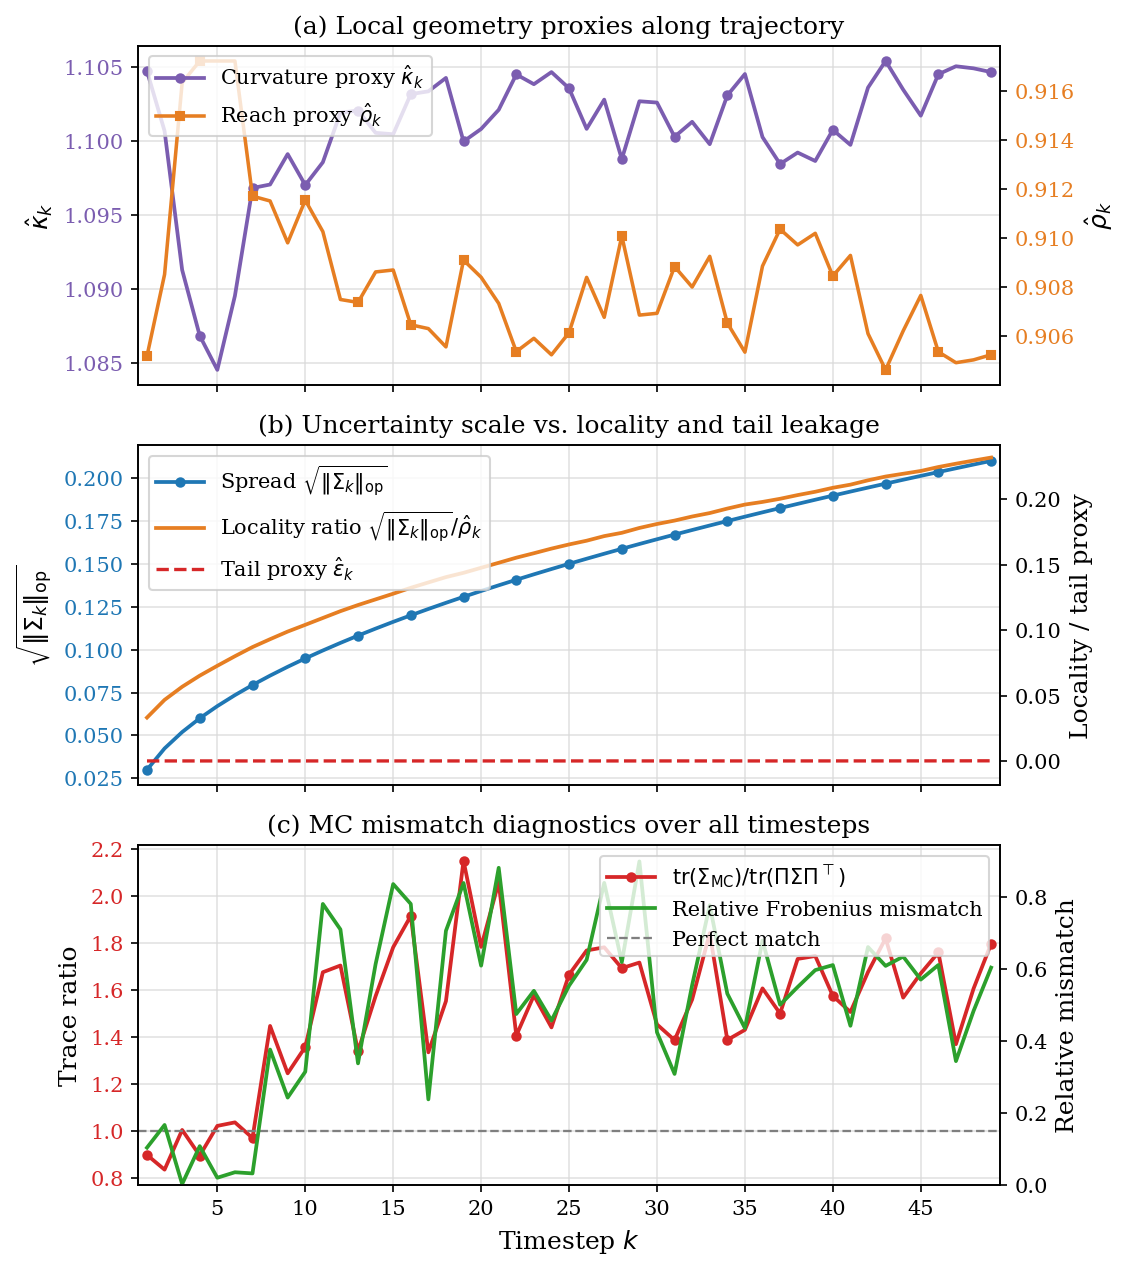

Peak MC mismatch at k=19: trace-ratio=2.150, locality-index=0.144
Median trace-ratio=1.573, median relative Frobenius=0.553


In [15]:
from matplotlib.ticker import MaxNLocator

# Compute tail proxy from existing diagnostics
tail_proxy = np.zeros(n_vars)
for k in range(n_vars):
    rho_k = diag_results['rho'][k]
    s_k = diag_results['spread'][k]
    if np.isfinite(rho_k) and s_k > 1e-12:
        tail_proxy[k] = np.exp(-0.5 * (rho_k / max(s_k, 1e-12))**2)
    else:
        tail_proxy[k] = 0.0

colors_td = {
    'purple': '#7b5db0', 'orange': '#e67e22', 'blue': '#1f77b4',
    'red': '#d62728', 'green': '#2ca02c', 'gray': '#7f7f7f'
}
marker_stride = max(1, n_vars // 14)

fig, axes = plt.subplots(3, 1, figsize=(7.6, 8.6), sharex=True)

def _style_ax(axis):
    axis.grid(True, color='#d9d9d9', alpha=0.75, linewidth=0.8)
    axis.set_xlim(0.5, n_vars + 0.5)
    axis.xaxis.set_major_locator(MaxNLocator(nbins=10, integer=True))

# (a) curvature / reach
ax = axes[0]
l1 = ax.plot(timesteps, diag_results['kappa'], color=colors_td['purple'],
             marker='o', ms=4.0, markevery=marker_stride, lw=1.8,
             label=r'Curvature proxy $\hat\kappa_k$')
ax.set_ylabel(r'$\hat\kappa_k$'); ax.tick_params(axis='y', labelcolor=colors_td['purple'])
_style_ax(ax)
ax2 = ax.twinx()
reach = diag_results['rho'].copy()
finite = np.isfinite(reach)
if np.any(finite):
    reach_cap = np.percentile(reach[finite], 95)
    reach_plot = np.where(finite, np.minimum(reach, reach_cap), reach_cap)
else:
    reach_plot = np.ones_like(reach)
l2 = ax2.plot(timesteps, reach_plot, color=colors_td['orange'],
              marker='s', ms=3.4, markevery=marker_stride, lw=1.7,
              label=r'Reach proxy $\hat\rho_k$')
ax2.set_ylabel(r'$\hat\rho_k$'); ax2.tick_params(axis='y', labelcolor=colors_td['orange'])
handles = l1 + l2
ax2.legend(handles, [h.get_label() for h in handles], loc='upper left',
           handlelength=2.3, borderpad=0.35)
ax.set_title('(a) Local geometry proxies along trajectory')

# (b) spread, locality, tail
ax = axes[1]
l1 = ax.plot(timesteps, diag_results['spread'], color=colors_td['blue'],
             marker='o', ms=4.0, markevery=marker_stride, lw=1.8,
             label=r'Spread $\sqrt{\|\Sigma_k\|_{\mathrm{op}}}$')
ax.set_ylabel(r'$\sqrt{\|\Sigma_k\|_{\mathrm{op}}}$')
ax.tick_params(axis='y', labelcolor=colors_td['blue'])
_style_ax(ax)
ax2 = ax.twinx()
l2 = ax2.plot(timesteps, diag_results['locality'], color=colors_td['orange'],
              lw=1.8, label=r'Locality ratio $\sqrt{\|\Sigma_k\|_{\mathrm{op}}}/\hat\rho_k$')
l3 = ax2.plot(timesteps, tail_proxy, ls='--', color=colors_td['red'],
              lw=1.6, label=r'Tail proxy $\hat\varepsilon_k$')
ax2.set_ylabel('Locality / tail proxy')
aux_vals = np.concatenate([diag_results['locality'][np.isfinite(diag_results['locality'])],
                           tail_proxy[np.isfinite(tail_proxy)]])
if aux_vals.size > 0:
    aux_span = max(float(np.max(aux_vals)) - float(np.min(aux_vals)), 1e-6)
    ax2.set_ylim(min(0.0, float(np.min(aux_vals)) - 0.08*aux_span),
                 float(np.max(aux_vals)) + 0.04*aux_span)
handles = l1 + l2 + l3
ax2.legend(handles, [h.get_label() for h in handles], loc='upper left',
           handlelength=2.3, borderpad=0.35)
ax.set_title('(b) Uncertainty scale vs. locality and tail leakage')

# (c) MC mismatch
ax = axes[2]
l1 = ax.plot(timesteps, diag_results['rho_mc'], color=colors_td['red'],
             marker='o', ms=4.0, markevery=marker_stride, lw=1.8,
             label=r'$\mathrm{tr}(\Sigma_{\mathrm{MC}})/\mathrm{tr}(\Pi\Sigma\Pi^\top)$')
l0 = ax.axhline(1.0, color=colors_td['gray'], ls='--', lw=1.1, label='Perfect match')
ax.set_ylabel('Trace ratio'); ax.tick_params(axis='y', labelcolor=colors_td['red'])
_style_ax(ax)
ax2 = ax.twinx()
l2 = ax2.plot(timesteps, diag_results['delta_mc'], color=colors_td['green'],
              lw=1.8, label='Relative Frobenius mismatch')
ax2.set_ylabel('Relative mismatch'); ax2.set_ylim(bottom=0.0)
handles = l1 + l2 + [l0]
ax2.legend(handles, [h.get_label() for h in handles], loc='upper right',
           handlelength=2.3, borderpad=0.35)
ax.set_title('(c) MC mismatch diagnostics over all timesteps')
ax.set_xlabel('Timestep $k$')

fig.tight_layout(h_pad=0.95)
plt.show()

# Print summary matching original script
peak_idx = int(np.nanargmax(diag_results['rho_mc']))
print(f'Peak MC mismatch at k={peak_idx+1}: '
      f'trace-ratio={diag_results["rho_mc"][peak_idx]:.3f}, '
      f'locality-index={diag_results["locality"][peak_idx]:.3f}')
print(f'Median trace-ratio={np.nanmedian(diag_results["rho_mc"]):.3f}, '
      f'median relative Frobenius={np.nanmedian(diag_results["delta_mc"]):.3f}')

## 8b. Overconfidence Visual & Metrics

Isotropic noise scaling study at the terminal pose: linearized vs. MC ellipses,
plus quantitative overconfidence ratio and Frobenius difference.

In [16]:
# Run isotropic overconfidence study at terminal pose
oc_noise_scales = [0.5, 1, 2, 4, 8]
n_mc_oc = 500
k_oc = n_vars - 1
i3_oc = k_oc * 3
x_oc = x_opt[:, k_oc]
base_unc_oc = unconstrained_cov[i3_oc:i3_oc+3, i3_oc:i3_oc+3]
geom_oc = estimate_local_geometry(x_oc, probe_pos_sub[:, k_oc],
                                   probe_radius, box_corners_box_frame)
Pi_oc = geom_oc['projector']

oc_tr_marg = []; oc_tr_emp = []; oc_frob = []
oc_mc_proj = []; oc_emp_cov = []; oc_marg_cov = []

print('Running isotropic overconfidence study...')
for alpha in oc_noise_scales:
    Sigma_oc = alpha**2 * base_unc_oc
    Sigma_lin_xy = (Pi_oc @ Sigma_oc @ Pi_oc.T)[:2, :2]
    oc_marg_cov.append(Sigma_lin_xy)
    samples = np.random.multivariate_normal(x_oc, Sigma_oc, n_mc_oc)
    projected = []
    for j in range(n_mc_oc):
        proj, ok = project_sample(samples[j], probe_pos_sub[:, k_oc],
                                  probe_radius, box_corners_box_frame)
        if ok:
            projected.append(proj)
    projected = np.array(projected)
    oc_mc_proj.append(projected)
    if len(projected) > 10:
        emp_cov_xy = np.cov(projected[:, :2].T, bias=False)
    else:
        emp_cov_xy = Sigma_lin_xy.copy()
    oc_emp_cov.append(emp_cov_xy)
    oc_tr_marg.append(np.trace(Sigma_lin_xy))
    oc_tr_emp.append(np.trace(emp_cov_xy))
    oc_frob.append(np.linalg.norm(emp_cov_xy - Sigma_lin_xy, 'fro'))
    ratio = np.trace(emp_cov_xy) / max(np.trace(Sigma_lin_xy), 1e-15)
    print(f'  alpha={alpha}: {len(projected)}/{n_mc_oc} valid, ratio={ratio:.3f}')

oc_tr_marg = np.array(oc_tr_marg)
oc_tr_emp = np.array(oc_tr_emp)
oc_frob = np.array(oc_frob)
print('Done.')

Running isotropic overconfidence study...


  alpha=0.5: 500/500 valid, ratio=1.341


  alpha=1: 500/500 valid, ratio=1.662


  alpha=2: 500/500 valid, ratio=1.036


  alpha=4: 500/500 valid, ratio=0.396


  alpha=8: 500/500 valid, ratio=0.119
Done.


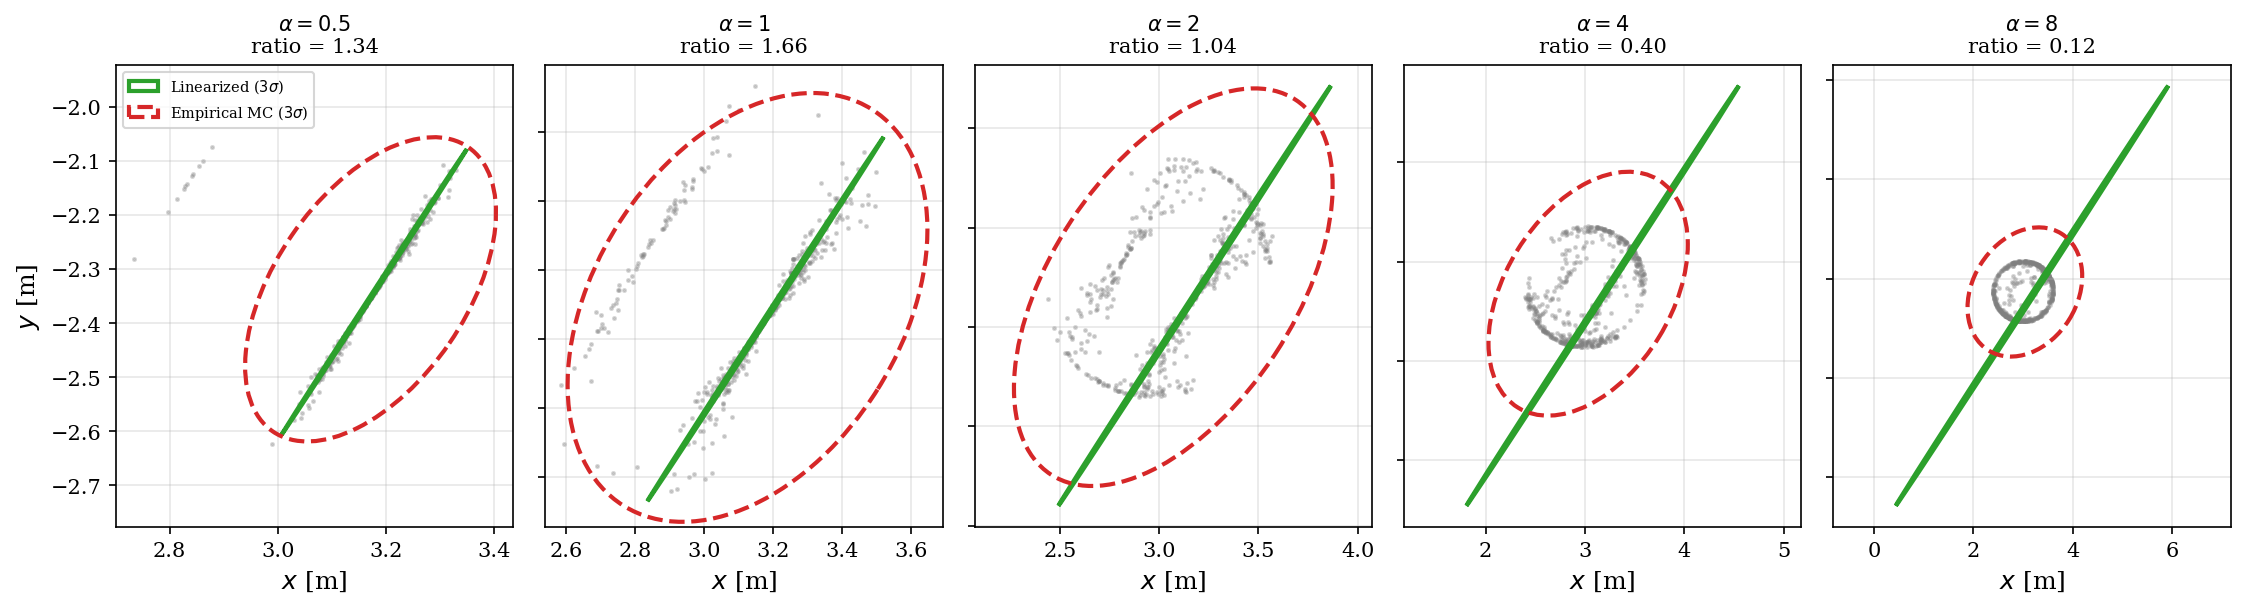

In [17]:
# Overconfidence visual: scatter + ellipses per noise scale
n_display = len(oc_noise_scales)
fig, axes = plt.subplots(1, n_display, figsize=(3.0 * n_display, 4))
if n_display == 1: axes = [axes]

for panel_idx, s in enumerate(range(n_display)):
    ax = axes[panel_idx]
    alpha = oc_noise_scales[s]
    proj = oc_mc_proj[s]
    emp_cov = oc_emp_cov[s]
    marg_cov = oc_marg_cov[s]
    ax.scatter(proj[:, 0], proj[:, 1], s=2, alpha=0.3, color='gray',
               zorder=1, rasterized=True)
    plot_cov_ellipse(ax, x_oc[:2], marg_cov, n_std=3,
                     edgecolor='tab:green', linewidth=2, zorder=3,
                     label=r'Linearized ($3\sigma$)' if panel_idx == 0 else None)
    emp_mean = np.mean(proj[:, :2], axis=0) if len(proj) > 0 else x_oc[:2]
    plot_cov_ellipse(ax, emp_mean, emp_cov, n_std=3,
                     edgecolor='tab:red', linewidth=2, linestyle='--', zorder=3,
                     label=r'Empirical MC ($3\sigma$)' if panel_idx == 0 else None)
    ratio = oc_tr_emp[s] / oc_tr_marg[s]
    ax.set_title(f'$\\alpha = {alpha}$\nratio = {ratio:.2f}', fontsize=10)
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_xlabel('$x$ [m]')
    if panel_idx == 0:
        ax.set_ylabel('$y$ [m]')
        ax.legend(fontsize=7, loc='upper left')
    else:
        ax.set_yticklabels([])
    ax.grid(True, alpha=0.3)

fig.subplots_adjust(left=0.05, right=0.99, wspace=0.08)
plt.show()

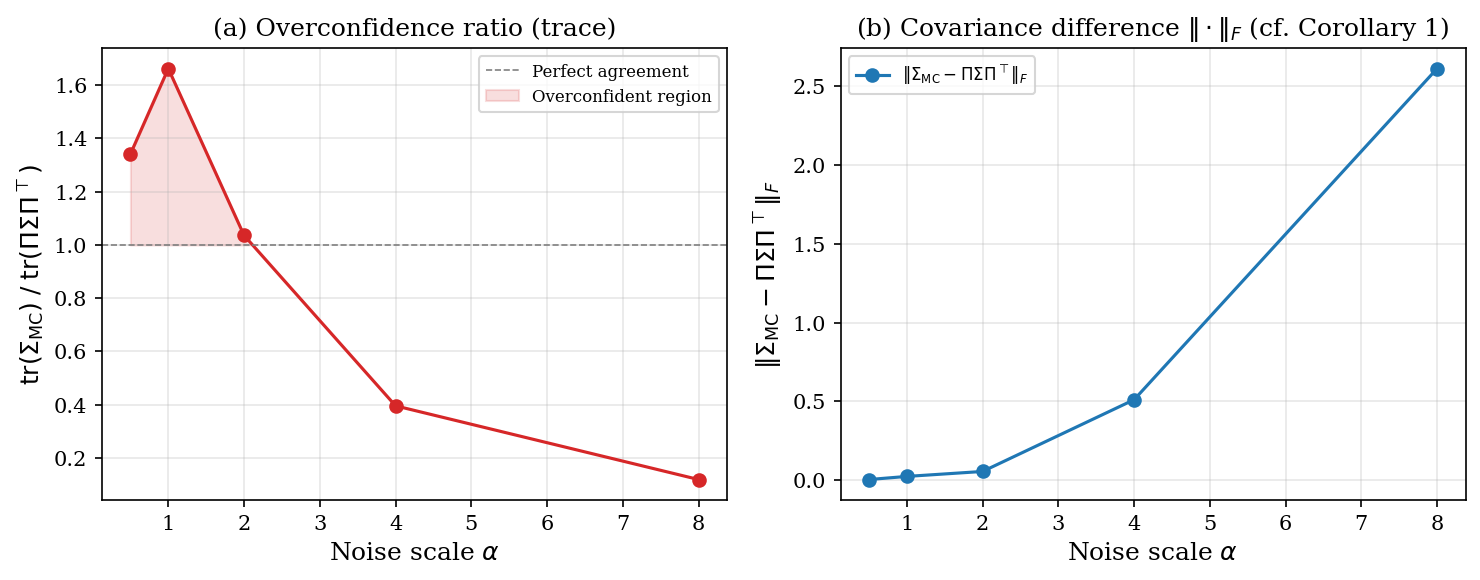

In [18]:
# Overconfidence metrics: ratio + Frobenius vs noise scale
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
scales = np.array(oc_noise_scales, dtype=float)
ratio = oc_tr_emp / oc_tr_marg

# (a) overconfidence ratio
ax = axes[0]
ax.plot(scales, ratio, 'o-', color='tab:red', lw=1.5, ms=6)
ax.axhline(1.0, color='gray', ls='--', lw=0.8, label='Perfect agreement')
ax.fill_between(scales, 1.0, ratio, where=(ratio > 1), interpolate=True,
                alpha=0.15, color='tab:red', label='Overconfident region')
ax.set_xlabel(r'Noise scale $\alpha$')
ax.set_ylabel(r'$\mathrm{tr}(\Sigma_{\mathrm{MC}}) \;/\; \mathrm{tr}(\Pi\Sigma\Pi^\top)$')
ax.set_title('(a) Overconfidence ratio (trace)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (b) Frobenius difference
ax = axes[1]
ax.plot(scales, oc_frob, 'o-', color='tab:blue', lw=1.5, ms=6,
        label=r'$\|\Sigma_{\mathrm{MC}} - \Pi\Sigma\Pi^\top\|_F$')
ax.set_xlabel(r'Noise scale $\alpha$')
ax.set_ylabel(r'$\|\Sigma_{\mathrm{MC}} - \Pi\Sigma\Pi^\top\|_F$')
ax.set_title(r'(b) Covariance difference $\|\cdot\|_F$ (cf. Corollary 1)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 8c. Directional Noise Figure

Three-panel figure comparing isotropic, normal-only, and tangent-only scaling:
- (a) Trace-ratio mismatch
- (b) Relative covariance mismatch
- (c) Locality index

Running directional noise study (3-panel)...


Done.


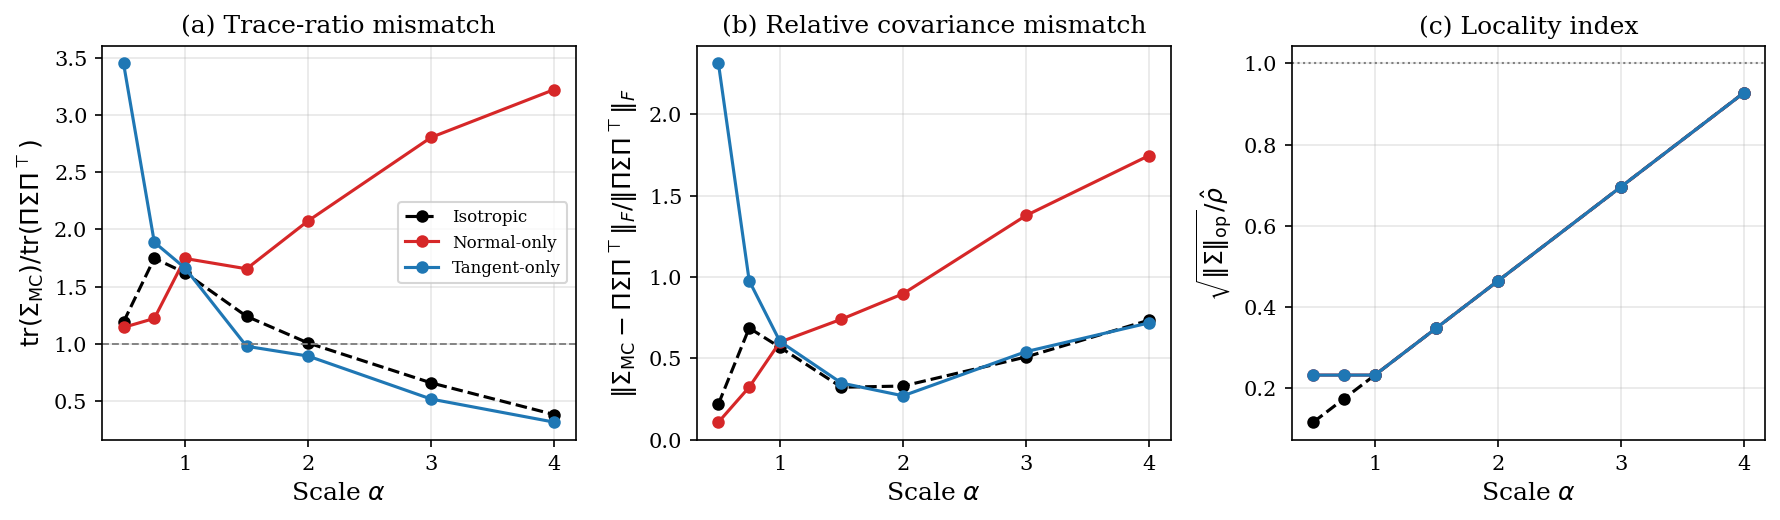

Normal-direction uncertainty causes the largest calibration mismatch.


In [19]:
# Recompute directional noise with trace ratios and Frobenius for 3-panel figure
dir_noise_scales = [0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0]
n_mc_dir = 200

# Get normal vector at terminal pose
geom_dir = estimate_local_geometry(x_oc, probe_pos_sub[:, k_oc],
                                    probe_radius, box_corners_box_frame)
Pi_dir = geom_dir['projector']
reach_dir = geom_dir['reach']

dir3_results = {}
mode_order = ['isotropic', 'normal_only', 'tangent_only']
for mode in mode_order:
    dir3_results[mode] = {'trace_ratio': [], 'frob_rel': [], 'locality_ratio': []}

print('Running directional noise study (3-panel)...')
for alpha in dir_noise_scales:
    for mode, (a_n, a_t) in [('isotropic', (alpha, alpha)),
                              ('normal_only', (alpha, 1.0)),
                              ('tangent_only', (1.0, alpha))]:
        A = a_t * (np.eye(3) - np.outer(n_hat, n_hat)) + a_n * np.outer(n_hat, n_hat)
        Sigma_scaled = A @ base_unc_oc @ A.T
        Sigma_lin_xy = (Pi_dir @ Sigma_scaled @ Pi_dir.T)[:2, :2]
        spread = float(np.sqrt(max(np.linalg.eigvalsh(Sigma_scaled)[-1], 0.0)))
        loc_ratio = spread / max(reach_dir, 1e-12) if np.isfinite(reach_dir) else 0.0

        samples = np.random.multivariate_normal(x_oc, Sigma_scaled, n_mc_dir)
        projected = []
        for j in range(n_mc_dir):
            proj, ok = project_sample(samples[j], probe_pos_sub[:, k_oc],
                                      probe_radius, box_corners_box_frame)
            if ok:
                projected.append(proj)
        if len(projected) > 10:
            projected = np.array(projected)
            emp_cov_xy = np.cov(projected[:, :2].T, bias=False)
            tr_ratio = np.trace(emp_cov_xy) / max(np.trace(Sigma_lin_xy), 1e-15)
            frob_rel = (np.linalg.norm(emp_cov_xy - Sigma_lin_xy, 'fro')
                        / max(np.linalg.norm(Sigma_lin_xy, 'fro'), 1e-15))
        else:
            tr_ratio = np.nan; frob_rel = np.nan
        dir3_results[mode]['trace_ratio'].append(tr_ratio)
        dir3_results[mode]['frob_rel'].append(frob_rel)
        dir3_results[mode]['locality_ratio'].append(loc_ratio)

for mode in mode_order:
    for key in dir3_results[mode]:
        dir3_results[mode][key] = np.array(dir3_results[mode][key])
print('Done.')

# Plot 1x3 directional noise figure
style_dn = {
    'isotropic': ('k', '--', 'Isotropic'),
    'normal_only': ('tab:red', '-', 'Normal-only'),
    'tangent_only': ('tab:blue', '-', 'Tangent-only'),
}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))

# (a) trace ratio
ax = axes[0]
for mode in mode_order:
    color, ls, label = style_dn[mode]
    ax.plot(dir_noise_scales, dir3_results[mode]['trace_ratio'],
            'o' + ls, color=color, label=label, ms=5)
ax.axhline(1.0, color='gray', ls='--', lw=0.9)
ax.set_xlabel(r'Scale $\alpha$')
ax.set_ylabel(r'$\mathrm{tr}(\Sigma_{\mathrm{MC}})/\mathrm{tr}(\Pi\Sigma\Pi^\top)$')
ax.set_title('(a) Trace-ratio mismatch')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

# (b) relative Frobenius mismatch
ax = axes[1]
for mode in mode_order:
    color, ls, label = style_dn[mode]
    ax.plot(dir_noise_scales, dir3_results[mode]['frob_rel'],
            'o' + ls, color=color, label=label, ms=5)
ax.set_xlabel(r'Scale $\alpha$')
ax.set_ylabel(r'$\|\Sigma_{\mathrm{MC}}-\Pi\Sigma\Pi^\top\|_F / \|\Pi\Sigma\Pi^\top\|_F$')
ax.set_title('(b) Relative covariance mismatch')
ax.grid(True, alpha=0.3)

# (c) locality ratio
ax = axes[2]
for mode in mode_order:
    color, ls, label = style_dn[mode]
    ax.plot(dir_noise_scales, dir3_results[mode]['locality_ratio'],
            'o' + ls, color=color, label=label, ms=5)
ax.axhline(1.0, color='gray', ls=':', lw=1.0)
ax.set_xlabel(r'Scale $\alpha$')
ax.set_ylabel(r'$\sqrt{\|\Sigma\|_{\mathrm{op}}}/\hat\rho$')
ax.set_title('(c) Locality index')
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()
print('Normal-direction uncertainty causes the largest calibration mismatch.')